# 10 — Complexity, Recoverability, and Final Figures

Goal:
- Consolidate all previous results.
- Build final A&C-ready summary tables.
- Generate high-insight figures:
  1. Recoverability hierarchy
  2. PySR vs baseline comparison
  3. Complexity vs recoverability
  4. Redshift/scale localization
  5. Robustness and uncertainty summary

This notebook performs no new training.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..").resolve()

RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"
FINAL_FIGURES = FIGURES / "final"
TABLES = PROJECT_ROOT / "tables"

for path in [RESULTS, FIGURES, FINAL_FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results:", RESULTS)
print("Final figures:", FINAL_FIGURES)
print("Tables:", TABLES)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression
Results: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results
Final figures: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final
Tables: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/tables


In [3]:
DATA_TAG = "n100_validation"

target_order = [
    "sigma8",
    "R_mfp",
    "log10_LX",
    "log10_Tvir",
    "zeta",
]

target_labels = {
    "sigma8": r"$\sigma_8$",
    "R_mfp": r"$R_{\rm mfp}$",
    "log10_LX": r"$\log_{10}L_X$",
    "log10_Tvir": r"$\log_{10}T_{\rm vir}$",
    "zeta": r"$\zeta$",
}

print("Data tag:", DATA_TAG)

Data tag: n100_validation


In [4]:
baseline_results = pd.read_csv(RESULTS / f"baseline_results_{DATA_TAG}.csv")
baseline_recoverability = pd.read_csv(
    RESULTS / f"baseline_recoverability_hierarchy_{DATA_TAG}.csv"
)

pysr_results = pd.read_csv(RESULTS / f"pysr_results_{DATA_TAG}.csv")
pysr_best = pd.read_csv(RESULTS / f"pysr_best_results_{DATA_TAG}.csv")
pysr_vs_baseline = pd.read_csv(
    RESULTS / f"pysr_vs_baseline_comparison_{DATA_TAG}.csv"
)

ablation_results = pd.read_csv(
    RESULTS / f"redshift_scale_ablation_results_{DATA_TAG}.csv"
)
ablation_summary = pd.read_csv(
    RESULTS / f"redshift_scale_ablation_summary_{DATA_TAG}.csv"
)

noise_results = pd.read_csv(
    RESULTS / f"noise_robustness_results_{DATA_TAG}.csv"
)
missing_results = pd.read_csv(
    RESULTS / f"missing_channel_results_{DATA_TAG}.csv"
)

bootstrap_summary = pd.read_csv(
    RESULTS / f"bootstrap_summary_rf_{DATA_TAG}.csv"
)

print("Loaded all result tables.")

Loaded all result tables.


In [5]:
required_targets = set(target_order)

for df_name, df in [
    ("baseline_results", baseline_results),
    ("pysr_results", pysr_results),
    ("ablation_summary", ablation_summary),
    ("bootstrap_summary", bootstrap_summary),
]:
    assert required_targets.issubset(set(df["target"])), df_name

print("All expected targets present.")

All expected targets present.


In [6]:
master = pysr_vs_baseline.copy()

ablation_comp = ablation_summary[[
    "target",
    "best_ablation_group",
    "best_ablation_r2",
    "delta_best_minus_full",
]]

bootstrap_comp = bootstrap_summary[[
    "target",
    "r2",
    "coverage_1sigma",
    "coverage_2sigma",
    "spearman_uncertainty_error",
]].rename(columns={
    "r2": "bootstrap_rf_r2",
})

master = master.merge(ablation_comp, on="target", how="left")
master = master.merge(bootstrap_comp, on="target", how="left")

master["target_label"] = master["target"].map(target_labels)

master = master.set_index("target").loc[target_order].reset_index()

master

,target,pysr_best_r2,pysr_best_mae,pysr_feature_representation,pysr_complexity,pysr_equation,baseline_model,baseline_feature_representation,baseline_best_r2,baseline_best_mae,r2_gap_pysr_minus_baseline,best_ablation_group,best_ablation_r2,delta_best_minus_full,bootstrap_rf_r2,coverage_1sigma,coverage_2sigma,spearman_uncertainty_error,target_label
0,sigma8,0.981022,0.005626,raw_scaled,5,sqrt(0.0682763*x15 + 0.68826646),MLP,raw_scaled,0.960441,0.007485,0.020581,z_12.0_high_k,0.979072,0.170433,0.798966,0.25,0.25,0.160902,$\sigma_8$
1,R_mfp,0.019634,4.777402,raw_scaled,9,(1.4850445 - (x18 + x54))*(x41 + 11.34017),MLP,log_scaled,0.175866,4.734829,-0.156232,z_8.0_low_k,0.207139,0.067553,0.135099,0.10,0.20,0.206015,$R_{\rm mfp}$
2,log10_LX,0.132253,0.908207,raw_scaled,5,x12 - x25 + 40.032467,Random Forest,log_scaled,-0.063462,0.985332,0.195715,z_10.0_all_k,-0.016499,0.048756,-0.007175,0.15,0.30,0.275188,$\log_{10}L_X$
3,log10_Tvir,-0.020773,0.395024,raw_scaled,8,log(-2.5181272*x3/x48 + 116.42029),Random Forest,raw_scaled,0.047715,0.384969,-0.068489,z_8.0_mid_k,0.071841,0.024126,0.034688,0.05,0.15,0.084211,$\log_{10}T_{\rm vir}$
4,zeta,-0.122861,16.194056,raw_scaled,10,32.542965*log(-x4*(-x8 - 0.5816575) + 4.0228972),Random Forest,log_scaled,-0.181410,16.362191,0.058549,z_10.0_low_k,0.130317,0.315026,-0.138591,0.05,0.40,0.009023,$\zeta$


In [7]:
def classify_recoverability(r2):
    if r2 >= 0.80:
        return "high"
    elif r2 >= 0.30:
        return "moderate"
    elif r2 >= 0.05:
        return "weak"
    else:
        return "poor"

master["symbolic_recoverability_class"] = master["pysr_best_r2"].apply(
    classify_recoverability
)

master["baseline_recoverability_class"] = master["baseline_best_r2"].apply(
    classify_recoverability
)

master

,target,pysr_best_r2,pysr_best_mae,pysr_feature_representation,pysr_complexity,pysr_equation,baseline_model,baseline_feature_representation,baseline_best_r2,baseline_best_mae,...,best_ablation_group,best_ablation_r2,delta_best_minus_full,bootstrap_rf_r2,coverage_1sigma,coverage_2sigma,spearman_uncertainty_error,target_label,symbolic_recoverability_class,baseline_recoverability_class
0,sigma8,0.981022,0.005626,raw_scaled,5,sqrt(0.0682763*x15 + 0.68826646),MLP,raw_scaled,0.960441,0.007485,...,z_12.0_high_k,0.979072,0.170433,0.798966,0.25,0.25,0.160902,$\sigma_8$,high,high
1,R_mfp,0.019634,4.777402,raw_scaled,9,(1.4850445 - (x18 + x54))*(x41 + 11.34017),MLP,log_scaled,0.175866,4.734829,...,z_8.0_low_k,0.207139,0.067553,0.135099,0.10,0.20,0.206015,$R_{\rm mfp}$,poor,weak
2,log10_LX,0.132253,0.908207,raw_scaled,5,x12 - x25 + 40.032467,Random Forest,log_scaled,-0.063462,0.985332,...,z_10.0_all_k,-0.016499,0.048756,-0.007175,0.15,0.30,0.275188,$\log_{10}L_X$,weak,poor
3,log10_Tvir,-0.020773,0.395024,raw_scaled,8,log(-2.5181272*x3/x48 + 116.42029),Random Forest,raw_scaled,0.047715,0.384969,...,z_8.0_mid_k,0.071841,0.024126,0.034688,0.05,0.15,0.084211,$\log_{10}T_{\rm vir}$,poor,poor
4,zeta,-0.122861,16.194056,raw_scaled,10,32.542965*log(-x4*(-x8 - 0.5816575) + 4.0228972),Random Forest,log_scaled,-0.181410,16.362191,...,z_10.0_low_k,0.130317,0.315026,-0.138591,0.05,0.40,0.009023,$\zeta$,poor,poor


In [8]:
master_table_path = TABLES / f"master_recoverability_summary_{DATA_TAG}.csv"

master.to_csv(master_table_path, index=False)

print("Saved master recoverability table to:", master_table_path)

Saved master recoverability table to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/tables/master_recoverability_summary_n100_validation.csv


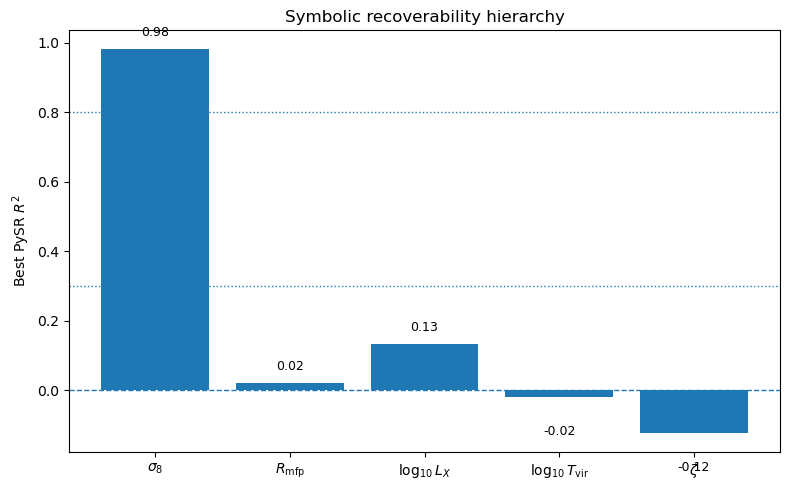

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_recoverability_hierarchy_n100_validation.png


In [9]:
plt.figure(figsize=(8, 5))

x = np.arange(len(master))

plt.bar(
    x,
    master["pysr_best_r2"],
)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axhline(0.8, linestyle=":", linewidth=1)
plt.axhline(0.3, linestyle=":", linewidth=1)

plt.xticks(x, master["target_label"], rotation=0)
plt.ylabel(r"Best PySR $R^2$")
plt.title("Symbolic recoverability hierarchy")

for i, value in enumerate(master["pysr_best_r2"]):
    plt.text(
        i,
        value + 0.03 if value >= 0 else value - 0.08,
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()

recoverability_fig_path = FINAL_FIGURES / f"fig_recoverability_hierarchy_{DATA_TAG}.png"
plt.savefig(recoverability_fig_path, dpi=300)
plt.show()

print("Saved:", recoverability_fig_path)

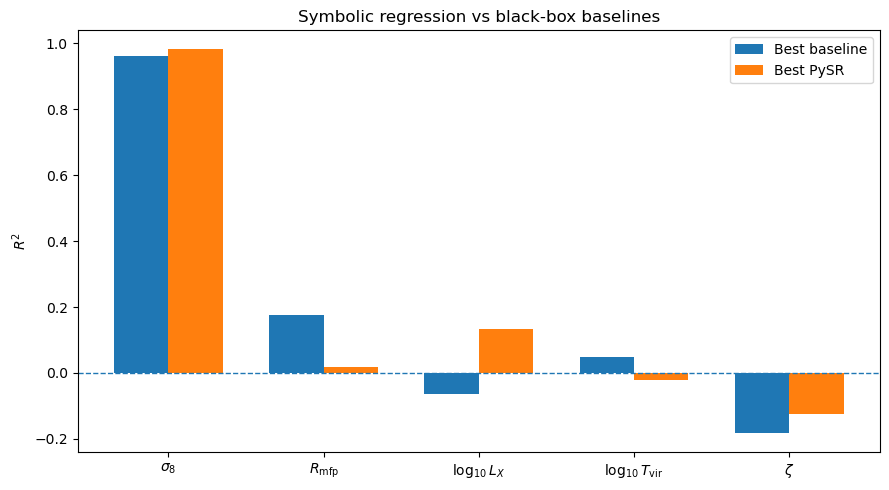

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_pysr_vs_baseline_n100_validation.png


In [10]:
plt.figure(figsize=(9, 5))

x = np.arange(len(master))
width = 0.35

plt.bar(
    x - width / 2,
    master["baseline_best_r2"],
    width=width,
    label="Best baseline",
)

plt.bar(
    x + width / 2,
    master["pysr_best_r2"],
    width=width,
    label="Best PySR",
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, master["target_label"])
plt.ylabel(r"$R^2$")
plt.title("Symbolic regression vs black-box baselines")
plt.legend()
plt.tight_layout()

comparison_fig_path = FINAL_FIGURES / f"fig_pysr_vs_baseline_{DATA_TAG}.png"
plt.savefig(comparison_fig_path, dpi=300)
plt.show()

print("Saved:", comparison_fig_path)

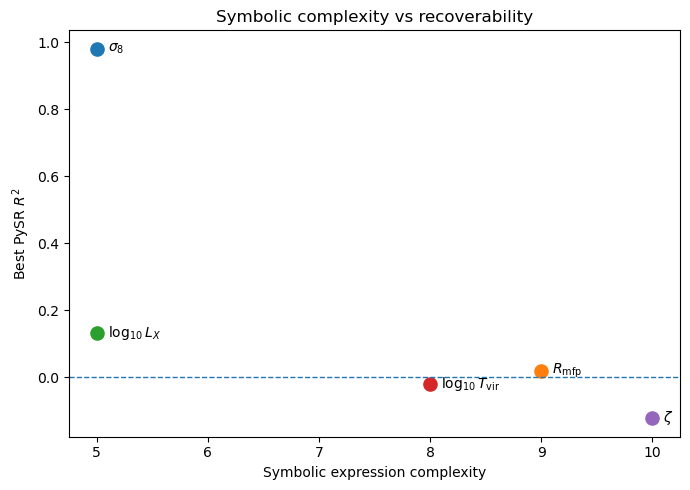

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_complexity_vs_recoverability_n100_validation.png


In [11]:
plt.figure(figsize=(7, 5))

for _, row in master.iterrows():
    plt.scatter(
        row["pysr_complexity"],
        row["pysr_best_r2"],
        s=90,
    )

    plt.text(
        row["pysr_complexity"] + 0.1,
        row["pysr_best_r2"],
        row["target_label"],
        fontsize=10,
        va="center",
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel("Symbolic expression complexity")
plt.ylabel(r"Best PySR $R^2$")
plt.title("Symbolic complexity vs recoverability")
plt.tight_layout()

complexity_fig_path = FINAL_FIGURES / f"fig_complexity_vs_recoverability_{DATA_TAG}.png"
plt.savefig(complexity_fig_path, dpi=300)
plt.show()

print("Saved:", complexity_fig_path)

In [12]:
localization_table = master[[
    "target",
    "target_label",
    "best_ablation_group",
    "best_ablation_r2",
    "delta_best_minus_full",
]].copy()

localization_table

,target,target_label,best_ablation_group,best_ablation_r2,delta_best_minus_full
0,sigma8,$\sigma_8$,z_12.0_high_k,0.979072,0.170433
1,R_mfp,$R_{\rm mfp}$,z_8.0_low_k,0.207139,0.067553
2,log10_LX,$\log_{10}L_X$,z_10.0_all_k,-0.016499,0.048756
3,log10_Tvir,$\log_{10}T_{\rm vir}$,z_8.0_mid_k,0.071841,0.024126
4,zeta,$\zeta$,z_10.0_low_k,0.130317,0.315026


In [13]:
localization_table_path = TABLES / f"information_localization_summary_{DATA_TAG}.csv"

localization_table.to_csv(localization_table_path, index=False)

print("Saved localization table to:", localization_table_path)

Saved localization table to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/tables/information_localization_summary_n100_validation.csv


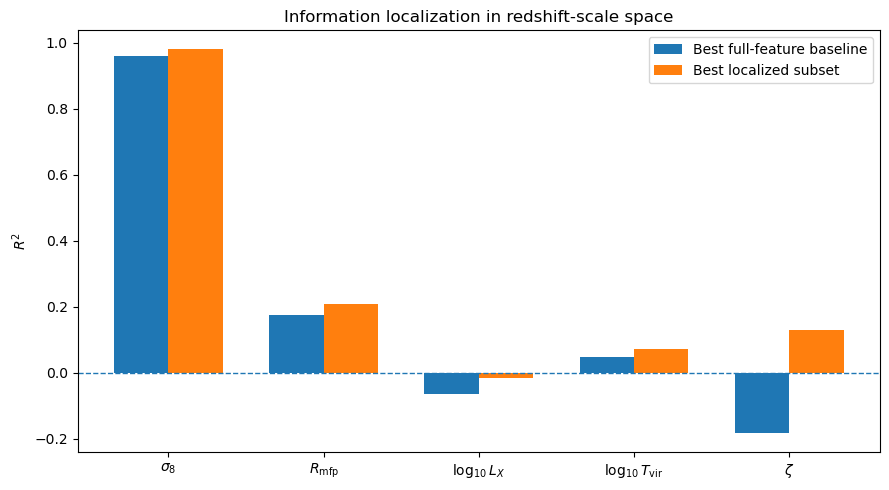

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_information_localization_n100_validation.png


In [14]:
plt.figure(figsize=(9, 5))

x = np.arange(len(master))
width = 0.35

plt.bar(
    x - width / 2,
    master["baseline_best_r2"],
    width=width,
    label="Best full-feature baseline",
)

plt.bar(
    x + width / 2,
    master["best_ablation_r2"],
    width=width,
    label="Best localized subset",
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, master["target_label"])
plt.ylabel(r"$R^2$")
plt.title("Information localization in redshift-scale space")
plt.legend()
plt.tight_layout()

localization_fig_path = FINAL_FIGURES / f"fig_information_localization_{DATA_TAG}.png"
plt.savefig(localization_fig_path, dpi=300)
plt.show()

print("Saved:", localization_fig_path)

In [15]:
clean_noisy = noise_results[
    (noise_results["experiment"] == "noise_robustness")
    & (noise_results["condition"] == "clean_train_noisy_test")
].copy()

noise_levels = sorted(clean_noisy["noise_level"].dropna().unique())

noise_heatmap = clean_noisy.pivot_table(
    index="target",
    columns="noise_level",
    values="r2",
)

noise_heatmap = noise_heatmap.loc[target_order, noise_levels]

noise_heatmap

noise_level,0.00,0.10,0.25,0.50,1.00
target,,,,,
sigma8,0.808639,0.797168,0.779251,0.731064,0.665518
R_mfp,0.139587,0.132819,0.182272,0.174129,-0.006172
log10_LX,-0.065255,-0.050129,-0.043667,-0.039253,-0.067651
log10_Tvir,0.047715,0.043358,0.046472,0.054177,0.046189
zeta,-0.184709,-0.194636,-0.231357,-0.105107,-0.146610


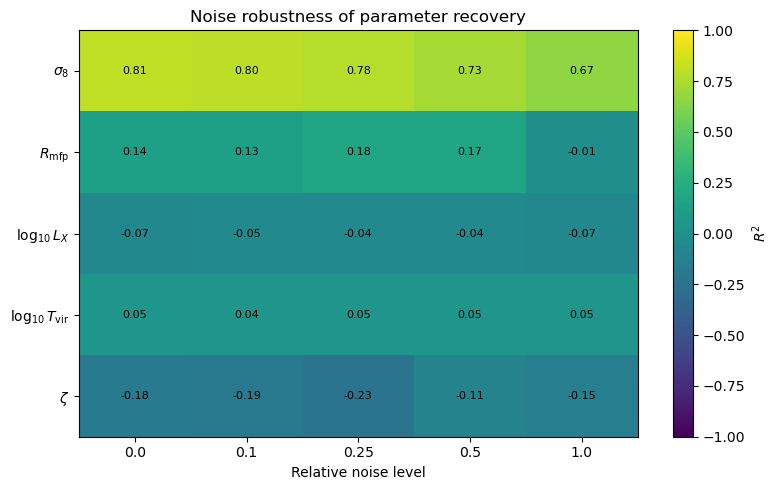

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_noise_robustness_heatmap_n100_validation.png


In [16]:
plt.figure(figsize=(8, 5))

im = plt.imshow(noise_heatmap.values, aspect="auto", vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(len(noise_levels)),
    labels=[str(x) for x in noise_levels],
)

plt.yticks(
    ticks=np.arange(len(target_order)),
    labels=[target_labels[t] for t in target_order],
)

plt.colorbar(im, label=r"$R^2$")
plt.xlabel("Relative noise level")
plt.title("Noise robustness of parameter recovery")

for i in range(noise_heatmap.shape[0]):
    for j in range(noise_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{noise_heatmap.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()

noise_final_fig_path = FINAL_FIGURES / f"fig_noise_robustness_heatmap_{DATA_TAG}.png"
plt.savefig(noise_final_fig_path, dpi=300)
plt.show()

print("Saved:", noise_final_fig_path)

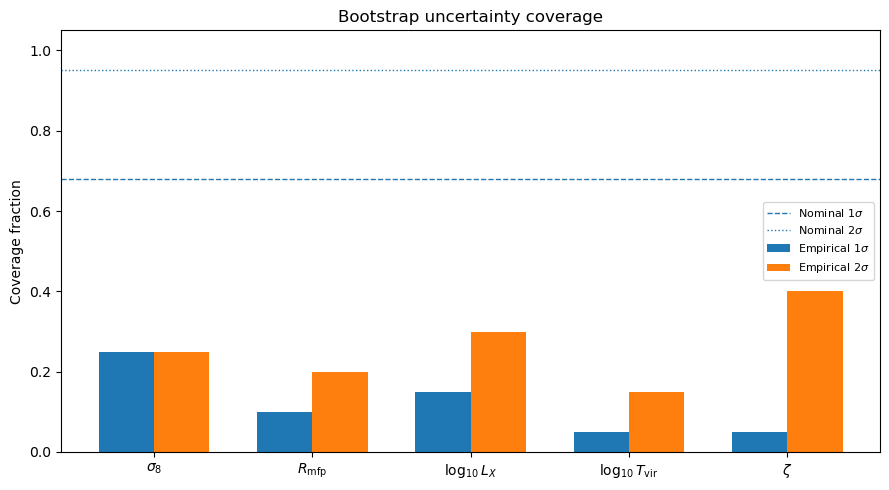

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_bootstrap_coverage_n100_validation.png


In [17]:
coverage_ordered = bootstrap_summary.set_index("target").loc[target_order].reset_index()

plt.figure(figsize=(9, 5))

x = np.arange(len(coverage_ordered))
width = 0.35

plt.bar(
    x - width / 2,
    coverage_ordered["coverage_1sigma"],
    width=width,
    label=r"Empirical $1\sigma$",
)

plt.bar(
    x + width / 2,
    coverage_ordered["coverage_2sigma"],
    width=width,
    label=r"Empirical $2\sigma$",
)

plt.axhline(0.68, linestyle="--", linewidth=1, label=r"Nominal $1\sigma$")
plt.axhline(0.95, linestyle=":", linewidth=1, label=r"Nominal $2\sigma$")

plt.xticks(x, [target_labels[t] for t in coverage_ordered["target"]])
plt.ylabel("Coverage fraction")
plt.ylim(0, 1.05)
plt.title("Bootstrap uncertainty coverage")
plt.legend(fontsize=8)
plt.tight_layout()

coverage_final_fig_path = FINAL_FIGURES / f"fig_bootstrap_coverage_{DATA_TAG}.png"
plt.savefig(coverage_final_fig_path, dpi=300)
plt.show()

print("Saved:", coverage_final_fig_path)

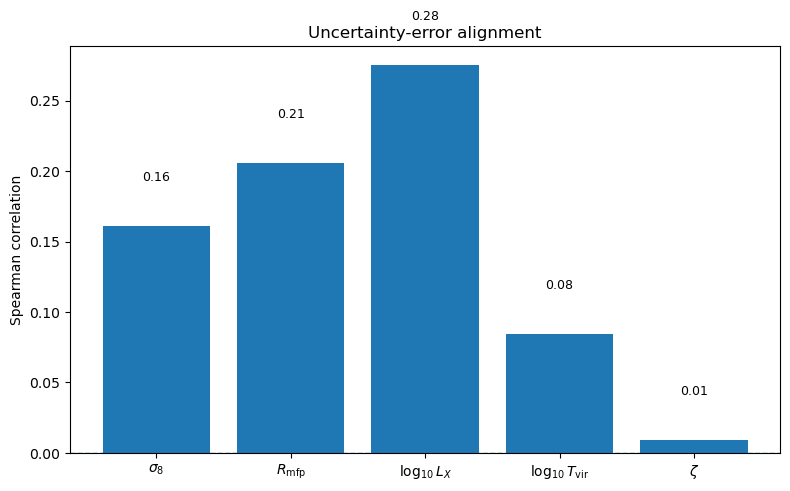

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_uncertainty_error_alignment_n100_validation.png


In [18]:
plt.figure(figsize=(8, 5))

x = np.arange(len(master))

plt.bar(
    x,
    master["spearman_uncertainty_error"],
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, master["target_label"])
plt.ylabel("Spearman correlation")
plt.title("Uncertainty-error alignment")

for i, value in enumerate(master["spearman_uncertainty_error"]):
    plt.text(
        i,
        value + 0.03 if value >= 0 else value - 0.06,
        f"{value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()

alignment_fig_path = FINAL_FIGURES / f"fig_uncertainty_error_alignment_{DATA_TAG}.png"
plt.savefig(alignment_fig_path, dpi=300)
plt.show()

print("Saved:", alignment_fig_path)

In [19]:
expression_table = master[[
    "target",
    "target_label",
    "pysr_best_r2",
    "pysr_complexity",
    "pysr_equation",
]].copy()

expression_table

,target,target_label,pysr_best_r2,pysr_complexity,pysr_equation
0,sigma8,$\sigma_8$,0.981022,5,sqrt(0.0682763*x15 + 0.68826646)
1,R_mfp,$R_{\rm mfp}$,0.019634,9,(1.4850445 - (x18 + x54))*(x41 + 11.34017)
2,log10_LX,$\log_{10}L_X$,0.132253,5,x12 - x25 + 40.032467
3,log10_Tvir,$\log_{10}T_{\rm vir}$,-0.020773,8,log(-2.5181272*x3/x48 + 116.42029)
4,zeta,$\zeta$,-0.122861,10,32.542965*log(-x4*(-x8 - 0.5816575) + 4.0228972)


In [20]:
expression_table_path = TABLES / f"symbolic_expression_summary_{DATA_TAG}.csv"

expression_table.to_csv(expression_table_path, index=False)

print("Saved symbolic expression table to:", expression_table_path)

Saved symbolic expression table to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/tables/symbolic_expression_summary_n100_validation.csv


In [21]:
manuscript_summary = master[[
    "target_label",
    "pysr_best_r2",
    "baseline_best_r2",
    "pysr_complexity",
    "best_ablation_group",
    "coverage_2sigma",
    "symbolic_recoverability_class",
]].copy()

manuscript_summary = manuscript_summary.rename(columns={
    "target_label": "Parameter",
    "pysr_best_r2": "Best PySR R2",
    "baseline_best_r2": "Best baseline R2",
    "pysr_complexity": "Complexity",
    "best_ablation_group": "Most informative subset",
    "coverage_2sigma": "2sigma coverage",
    "symbolic_recoverability_class": "Symbolic class",
})

manuscript_summary

,Parameter,Best PySR R2,Best baseline R2,Complexity,Most informative subset,2sigma coverage,Symbolic class
0,$\sigma_8$,0.981022,0.960441,5,z_12.0_high_k,0.25,high
1,$R_{\rm mfp}$,0.019634,0.175866,9,z_8.0_low_k,0.20,poor
2,$\log_{10}L_X$,0.132253,-0.063462,5,z_10.0_all_k,0.30,weak
3,$\log_{10}T_{\rm vir}$,-0.020773,0.047715,8,z_8.0_mid_k,0.15,poor
4,$\zeta$,-0.122861,-0.181410,10,z_10.0_low_k,0.40,poor


In [22]:
manuscript_summary_path = TABLES / f"manuscript_summary_table_{DATA_TAG}.csv"

manuscript_summary.to_csv(manuscript_summary_path, index=False)

print("Saved manuscript summary table to:", manuscript_summary_path)

Saved manuscript summary table to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/tables/manuscript_summary_table_n100_validation.csv


In [23]:
figure_registry = pd.DataFrame([
    {
        "figure": "Fig. 1",
        "file": str(recoverability_fig_path),
        "purpose": "Symbolic recoverability hierarchy across parameters",
    },
    {
        "figure": "Fig. 2",
        "file": str(comparison_fig_path),
        "purpose": "Compare PySR against strongest baseline model",
    },
    {
        "figure": "Fig. 3",
        "file": str(complexity_fig_path),
        "purpose": "Relate expression complexity to recoverability",
    },
    {
        "figure": "Fig. 4",
        "file": str(localization_fig_path),
        "purpose": "Show redshift/scale information localization",
    },
    {
        "figure": "Fig. 5",
        "file": str(noise_final_fig_path),
        "purpose": "Noise robustness across parameters",
    },
    {
        "figure": "Fig. 6",
        "file": str(coverage_final_fig_path),
        "purpose": "Bootstrap uncertainty coverage",
    },
    {
        "figure": "Fig. 7",
        "file": str(alignment_fig_path),
        "purpose": "Uncertainty-error alignment",
    },
])

figure_registry_path = TABLES / f"final_figure_registry_{DATA_TAG}.csv"

figure_registry.to_csv(figure_registry_path, index=False)

figure_registry

,figure,file,purpose
0,Fig. 1,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Symbolic recoverability hierarchy across param...
1,Fig. 2,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Compare PySR against strongest baseline model
2,Fig. 3,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Relate expression complexity to recoverability
3,Fig. 4,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Show redshift/scale information localization
4,Fig. 5,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Noise robustness across parameters
5,Fig. 6,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Bootstrap uncertainty coverage
6,Fig. 7,/Users/rudhresh/Desktop/Research/21cm_symbolic...,Uncertainty-error alignment


In [24]:
final_metadata = {
    "notebook": "10_complexity_recoverability_figures.ipynb",
    "data_tag": DATA_TAG,
    "purpose": "Consolidate all n=100 validation outputs into final analysis figures and tables.",
    "main_scientific_findings": {
        "recoverability_hierarchy": (
            "sigma8 is strongly recoverable, while astrophysical parameters "
            "show weak or poor recoverability in the n=100 validation dataset."
        ),
        "information_localization": (
            "sigma8 recoverability is strongly localized to early-redshift high-k information."
        ),
        "complexity": (
            "High symbolic recoverability can occur at low expression complexity, "
            "while higher complexity does not guarantee recovery for degenerate parameters."
        ),
        "uncertainty": (
            "Bootstrap uncertainty is under-calibrated for the current validation dataset."
        ),
    },
    "final_figures": figure_registry.to_dict(orient="records"),
}

final_metadata_path = RESULTS / f"final_analysis_metadata_{DATA_TAG}.json"

with open(final_metadata_path, "w") as f:
    json.dump(final_metadata, f, indent=2)

print("Saved final metadata to:", final_metadata_path)

Saved final metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/final_analysis_metadata_n100_validation.json


In [25]:
print("=" * 60)
print("Notebook 10 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)

print("\nFinal figures:")
for _, row in figure_registry.iterrows():
    print(f"{row['figure']}: {row['file']}")

print("\nFinal tables:")
print(" -", master_table_path)
print(" -", localization_table_path)
print(" -", expression_table_path)
print(" -", manuscript_summary_path)
print(" -", figure_registry_path)

print("\nFinal metadata:")
print(" -", final_metadata_path)

Notebook 10 completed successfully.
Dataset tag: n100_validation

Final figures:
Fig. 1: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_recoverability_hierarchy_n100_validation.png
Fig. 2: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_pysr_vs_baseline_n100_validation.png
Fig. 3: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_complexity_vs_recoverability_n100_validation.png
Fig. 4: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_information_localization_n100_validation.png
Fig. 5: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_noise_robustness_heatmap_n100_validation.png
Fig. 6: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_bootstrap_coverage_n100_validation.png
Fig. 7: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/final/fig_uncertainty_error_alignment_n100_validation.png

Final tables:
 - /User